<a href="https://colab.research.google.com/github/mruizbaidez04/Procesos-estoc-sticos-Stochastic-processes/blob/main/SimulacionPAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de Paseo Aleatorio Simple (PAS)

El objetivo de este notebook será simular paseos aleatorios simples para distintos parámetros, representándolos en gráficos. Incluimos los paquetes NumPy y Matplotlib.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

Comenzaremos creando una función `simular_PAS` que recibe tres argumentos:
- p: el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 (y por tanto la probabilidad de tomar el valor -1 sería $1-p$). En principio será un valor comprendido estríctamente (no necesariamente, pero en caso de ser 0 o 1 no es aleatorio) entre 0 y 1.
- reps: el número de trayectorias a simular. Un número natural.
- n: el número de pasos a simular en cada trayectoria. Un número natural.

La función devuelve un array de NumPy con dimensión `(reps, n)`, que contenga lo valores del PAS en cada paso para cada trayectoria.

In [ ]:
def simular_PAS(p,n,reps=1):

  # Input:

  # p: Es el parámetro principal del PAS. Determina la probabilidad en cada
  # paso de tomar el valor 1, y por tanto la de tomar el valor -1 (1-p).
  # El parámetro p debe estar entre 0 y 1.

  # n: El número de pasos a simular para cada trayectoria. Será un
  # número natural.

  # reps: El número de trayectorias a simular. Será un número natural.


  # Output:

  # output: La salida será un array de NumPy de dimensión (reps, n), que
  # contenga los valores del PAS en cada paso, para cada trayectoria.

  # ------------------------------------------------------------------ #

  # Comenzaremos creando la variable que genera el PAS

  valores = [1, -1] # Posibles valores de la variable.
  probabilidades = [p, 1-p] # Probabilidades de cada valor.

  muestra = np.random.choice(valores, size=(reps, n), p=probabilidades) # Shape: (reps, n)

  # Genera un array, de tamaño (reps, n), que contiene cada uno de los pasos
  # que se dan en cada trayectoria del PAS. Ahora, queremos generar el array
  # output que almacene los pasos acumulados en cada trayectoria.

  output = np.cumsum(muestra, axis=1) # Shape: (reps, n)

  # La función np.cumsum() devuelve la suma acumulada del array muestra, sobre
  # el eje 1. Esto es, cada columna del array output contiene la suma de
  # la correspondiente columna del array muestra con las columnas anteriores
  # de este array.

  return output  # Shape: (reps, n)

La función que hemos creado genera un array de dimensión `(reps, n)`, con cada uno de los pasos de cada trayectoria (es decir, solo contiene 1 o -1). A partir de este array, generamos el array `output` que devuelve la suma acumulada de las columnas del primer array.

## Gráficas

Generaremos acontinuación 3 gráficas, correspondientes a las trayectorias de PAS con parámetros 0.5, 0.6 y 0.4 respectivamente. Las aclaraciones correspondientes al código que las genera solo aparecerá en la primera.

<>:19: SyntaxWarning: invalid escape sequence '\i'
<>:19: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_4024/3735718282.py:19: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("$n \in \mathbb{N}$")


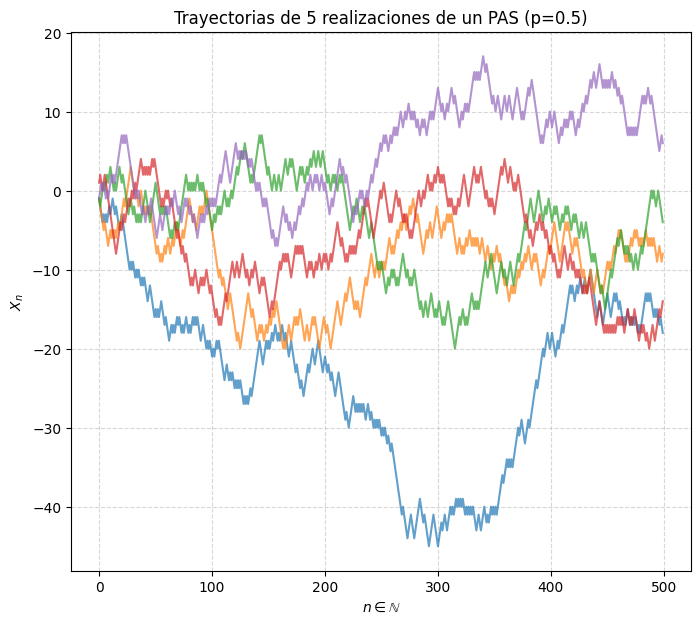

In [ ]:
# Comenzamos creando la simulación de 5 trayectorias de 500 pasos, con
# probabilidad 0.5.

pasos = 500
prob = 0.5

datos = simular_PAS(prob, pasos, 5)

# Generamos una gráfica, algo estirada verticalmente.
plt.figure(figsize=(8, 7))

# Matplotlib interpreta cada columna como una serie de datos distinta.
# Como datos tiene forma (reps, pasos), usamos la traspuesta de datos
# para que tenga la forma (pasos, reps).
plt.plot(datos.T, alpha=0.7, linewidth=1.5)

# Añadiremos título a la gráfica y etiquetas a los ejes.
plt.title(f"Trayectorias de 5 realizaciones de un PAS (p=0.5)")
plt.xlabel("$n \in \mathbb{N}$")
plt.ylabel("$X_n$")

# Añadimos una rejilla, con bastante transparencia, para que no quite
# atención a las trayectorias.
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\i'
<>:13: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_4024/318698820.py:13: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("$n \in \mathbb{N}$")


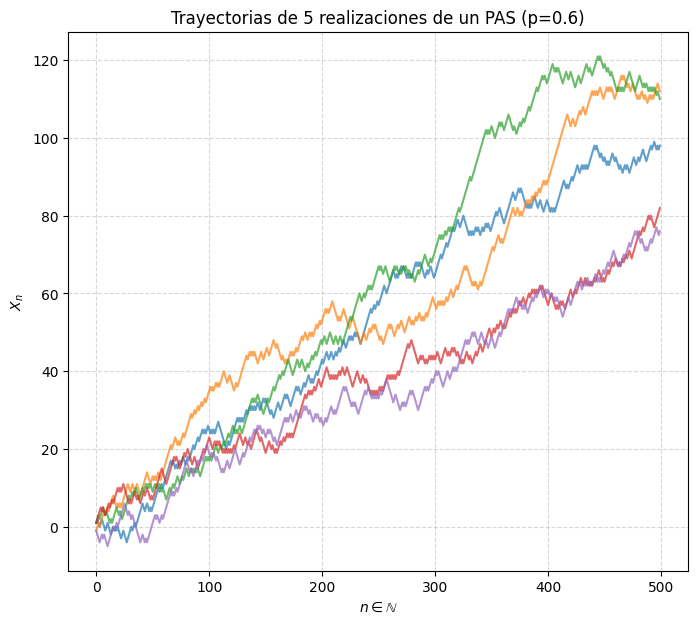

In [ ]:
# Simulación de 5 trayectorias de 500 pasos, con probabilidad 0.6.

pasos = 500
prob = 0.6

datos = simular_PAS(prob, pasos, 5)

plt.figure(figsize=(8, 7))

plt.plot(datos.T, alpha=0.7, linewidth=1.5)

plt.title(f"Trayectorias de 5 realizaciones de un PAS (p=0.6)")
plt.xlabel("$n \in \mathbb{N}$")
plt.ylabel("$X_n$")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\i'
<>:13: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_4024/4034578940.py:13: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("$n \in \mathbb{N}$")


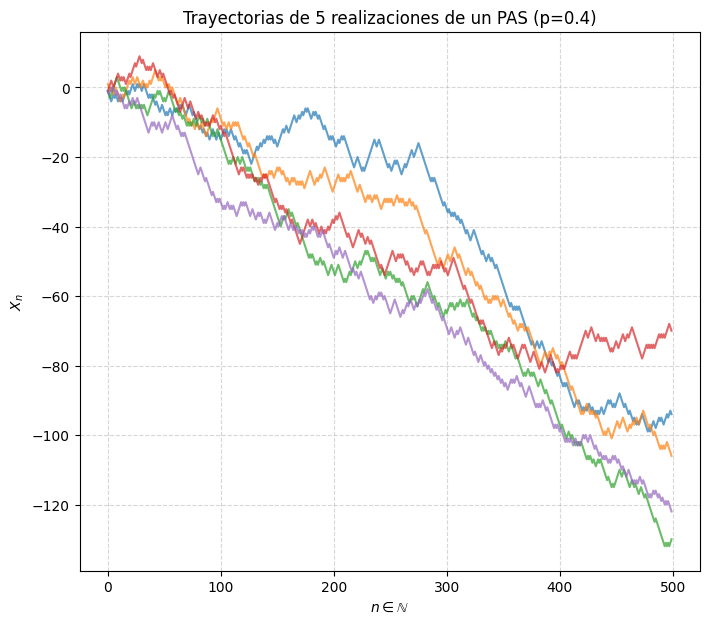

In [ ]:
# Simulación de 5 trayectorias de 500 pasos, con probabilidad 0.4.

pasos = 500
prob = 0.4

datos = simular_PAS(prob, pasos, 5)

plt.figure(figsize=(8, 7))

plt.plot(datos.T, alpha=0.7, linewidth=1.5)

plt.title(f"Trayectorias de 5 realizaciones de un PAS (p=0.4)")
plt.xlabel("$n \in \mathbb{N}$")
plt.ylabel("$X_n$")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Ahora, crearemos gráficas en las que aparezca, aparte de las trayectorias, la media teórica y un entorno, alrededor de la media, de amplitud $\pm1$ y $\pm2$ desviaciones típicas teóricas. Para ello creamos funciones para calcular las medias teóricas y las desviaciones típicas teóricas.

In [ ]:
def media_PAS (p, n):
  # La función media_PAS devolverá un array 1-dimensional que contenga las
  # medias teorícas de un PAS de n pasos con probabilidad p.

  # input:

  # n = número de pasos del PAS.
  # p = probabilidad del PAS.

  # output:

  # Un array 1-dimensional de NumPy de longitud n que contenga las medias
  # teóricas del PAS en cada paso.

  x = np.arange(1, n+1)

  return (2*p-1)*x

In [ ]:
def desviaciontipica_PAS (p, n):
  # La función desviaciontipica_PAS devolverá un array 1-dimensional que
  # contenga las desviaciones típicas teóricas de un PAS de n pasos
  # con probabilidad p.

  # input:

  # n = número de pasos del PAS.
  # p = probabilidad del PAS.

  # output:

  # Un array 1-dimensional de NumPy de longitud n que contenga las desviaciones
  # típicas teóricas del PAS en cada paso.

  x = np.arange(1, n+1)

  return np.sqrt(4*p*(1-p)*x)

A continuación, crearemos los gráficos mencionados, para probabilidades 0.5, 0.75 y 0.95 respectivamente.

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\i'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_4024/3052933835.py:25: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(x, media + desvtip, media - desvtip ,label="$\pm \sigma$", color='k', alpha=0.2)
/tmp/ipykernel_4024/3052933835.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(x, media + 2*desvtip, media - 2*desvtip ,label="$\pm 2\sigma$", color='grey', alpha=0.2)
/tmp/ipykernel_4024/3052933835.py:29: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("$n \in \mathbb{N}$")


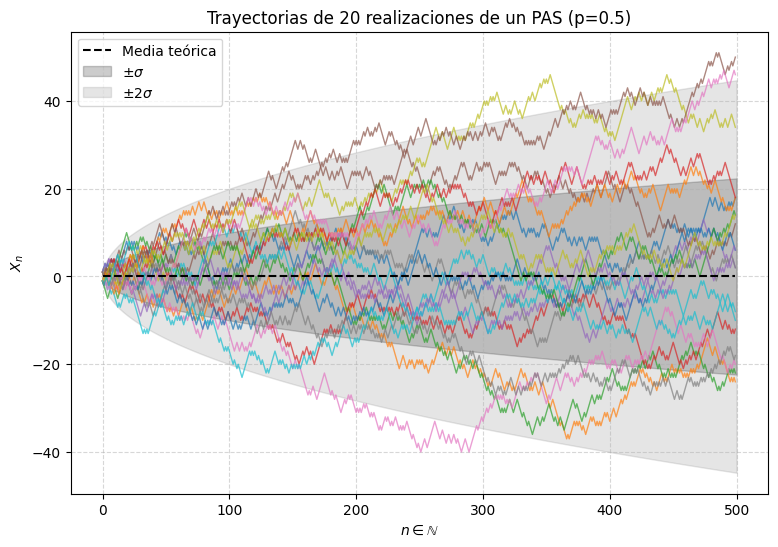

In [ ]:
# Simulación de 20 trayectorias del PAS con p=0.5, graficando la media teórica
# y un entorno alrededor de la media, con amplitud múltiplo de la desviación
# típica teórica.

pasos = 500
prob = 0.5

datos = simular_PAS(prob, pasos, 20)

plt.figure(figsize=(9, 6))

plt.plot(datos.T, alpha=0.7, linewidth=1)

# Calculamos la media y la desviación típica teórica
media = media_PAS(prob, pasos)
desvtip = desviaciontipica_PAS(prob, pasos)

# Graficamos la media teórica
plt.plot(media, label="Media teórica", linestyle="--", color='k')

x=np.arange(1, pasos+1)

# Graficamos la región que dista de la media teórica menos de 1 o 2 veces la
# desviación típica
plt.fill_between(x, media + desvtip, media - desvtip ,label="$\pm \sigma$", color='k', alpha=0.2)
plt.fill_between(x, media + 2*desvtip, media - 2*desvtip ,label="$\pm 2\sigma$", color='grey', alpha=0.2)

plt.title(f"Trayectorias de 20 realizaciones de un PAS (p=0.5)")
plt.xlabel("$n \in \mathbb{N}$")
plt.ylabel("$X_n$")

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\i'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_4024/1482631452.py:25: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(x, media + desvtip, media - desvtip ,label="$\pm \sigma$", color='k', alpha=0.2)
/tmp/ipykernel_4024/1482631452.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(x, media + 2*desvtip, media - 2*desvtip ,label="$\pm 2\sigma$", color='grey', alpha=0.2)
/tmp/ipykernel_4024/1482631452.py:29: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("$n \in \mathbb{N}$")


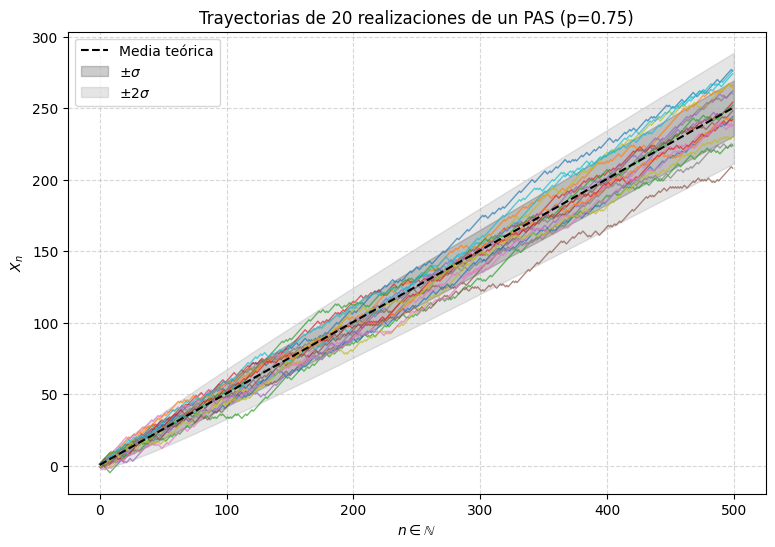

In [ ]:
# Simulación de 20 trayectorias del PAS con p=0.75, graficando la media teórica
# y un entorno alrededor de la media, con amplitud múltiplo de la desviación
# típica teórica.

pasos = 500
prob = 0.75

datos = simular_PAS(prob, pasos, 20)

plt.figure(figsize=(9, 6))

plt.plot(datos.T, alpha=0.7, linewidth=1)

# Calculamos la media y la desviación típica teórica
media = media_PAS(prob, pasos)
desvtip = desviaciontipica_PAS(prob, pasos)

# Graficamos la media teórica
plt.plot(media, label="Media teórica", linestyle="--", color='k')

x=np.arange(1, pasos+1)

# Graficamos la región que dista de la media teórica menos de 1 o 2 veces la
# desviación típica
plt.fill_between(x, media + desvtip, media - desvtip ,label="$\pm \sigma$", color='k', alpha=0.2)
plt.fill_between(x, media + 2*desvtip, media - 2*desvtip ,label="$\pm 2\sigma$", color='grey', alpha=0.2)

plt.title(f"Trayectorias de 20 realizaciones de un PAS (p=0.75)")
plt.xlabel("$n \in \mathbb{N}$")
plt.ylabel("$X_n$")

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\i'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_4024/3279362507.py:25: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(x, media + desvtip, media - desvtip ,label="$\pm \sigma$", color='k', alpha=0.2)
/tmp/ipykernel_4024/3279362507.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(x, media + 2*desvtip, media - 2*desvtip ,label="$\pm 2\sigma$", color='grey', alpha=0.2)
/tmp/ipykernel_4024/3279362507.py:29: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("$n \in \mathbb{N}$")


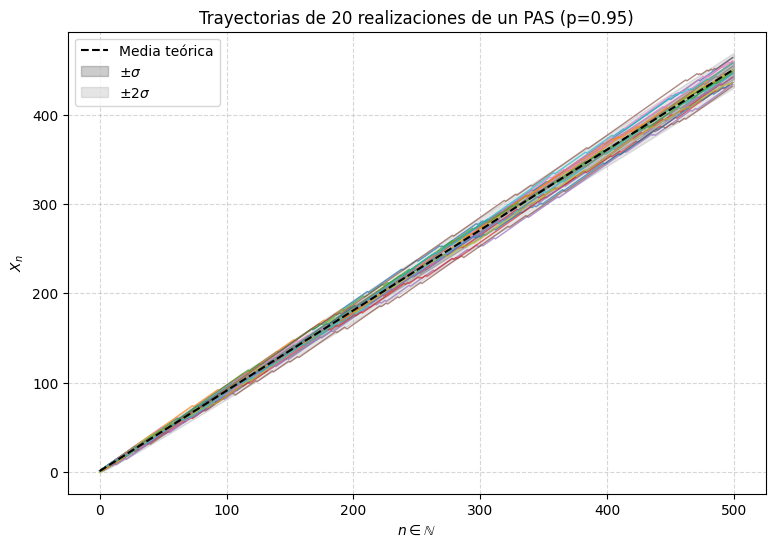

In [ ]:
# Simulación de 20 trayectorias del PAS con p=0.95, graficando la media teórica
# y un entorno alrededor de la media, con amplitud múltiplo de la desviación
# típica teórica.

pasos = 500
prob = 0.95

datos = simular_PAS(prob, pasos, 20)

plt.figure(figsize=(9, 6))

plt.plot(datos.T, alpha=0.7, linewidth=1)

# Calculamos la media y la desviación típica teórica
media = media_PAS(prob, pasos)
desvtip = desviaciontipica_PAS(prob, pasos)

# Graficamos la media teórica
plt.plot(media, label="Media teórica", linestyle="--", color='k')

x=np.arange(1, pasos+1)

# Graficamos la región que dista de la media teórica menos de 1 o 2 veces la
# desviación típica
plt.fill_between(x, media + desvtip, media - desvtip ,label="$\pm \sigma$", color='k', alpha=0.2)
plt.fill_between(x, media + 2*desvtip, media - 2*desvtip ,label="$\pm 2\sigma$", color='grey', alpha=0.2)

plt.title(f"Trayectorias de 20 realizaciones de un PAS (p=0.95)")
plt.xlabel("$n \in \mathbb{N}$")
plt.ylabel("$X_n$")

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()

Finalmente, crearemos una gráfica donde podamos ver como se comparan la medía teórica con las medias empíricas para 5, 100, 200, 500 y 1000 trayectorias de un PAS con $p=0.5$.

In [ ]:
def media_empirica_PAS (datos):
  # La función media_empirica_PAS devolverá un array de NumPy 1-dimensional,
  # que calcule la media por columnas a partir de un array 2-dimensional 'datos'.

  # input:

  # datos = array 2-dimensional (shape=(reps, n)), que contenga los 'n' pasos de
  # 'reps' trayectorias de un PAS

  # output:

  # un array 1-dimensional que contenga la media de las columnas del array datos.

  return np.mean(datos, axis=0) # length = n

<>:31: SyntaxWarning: invalid escape sequence '\i'
<>:31: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_4024/899453056.py:31: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("$n \in \mathbb{N}$")


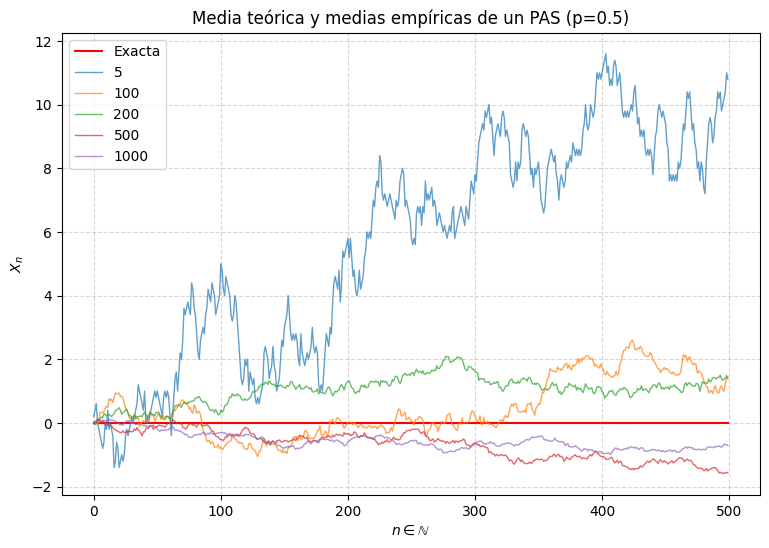

In [ ]:
# Comparación de la media teórica con las medias empíricas para 5, 100, 200,
# 500 y 1000 trayectorias de un PAS con p=0.5

pasos = 500
prob = 0.5

plt.figure(figsize=(9, 6))

# Graficamos la media teórica
plt.plot(media_PAS(prob, pasos), label="Exacta", color='r', linewidth=1.5)

# Generamos una simulación de PAS con pasos 5, 100, 200, 500 y 1000
# respectivamente, y despues graficaremos el vector de medias en cada paso
# usando la función media_empirica_PAS.
datos1 = simular_PAS(prob, pasos, 5)
plt.plot(media_empirica_PAS(datos1), alpha=0.7, linewidth=1, label='5')

datos2 = simular_PAS(prob, pasos, 100)
plt.plot(media_empirica_PAS(datos2), alpha=0.7, linewidth=1, label='100')

datos3 = simular_PAS(prob, pasos, 200)
plt.plot(media_empirica_PAS(datos3), alpha=0.7, linewidth=1, label='200')

datos4 = simular_PAS(prob, pasos, 500)
plt.plot(media_empirica_PAS(datos4), alpha=0.7, linewidth=1, label='500')

datos5 = simular_PAS(prob, pasos, 1000)
plt.plot(media_empirica_PAS(datos5), alpha=0.7, linewidth=1, label='1000')

plt.title(f"Media teórica y medias empíricas de un PAS (p=0.5)")
plt.xlabel("$n \in \mathbb{N}$")
plt.ylabel("$X_n$")

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()